In [ ]:
# Clone repo (if running in Colab)
!git clone https://github.com/LizaGenke/Chemometric-approaches-to-hyperspectral-processing.git

# Navigate into the cloned repository
%cd Chemometric-approaches-to-hyperspectral-processing

# Install dependencies
!pip install -r requirements.txt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
# Define the path to your data and result folders in Google Drive
# data_path="data"
# results_dir = "results"
data_path = '/content/drive/MyDrive/Chemometrics_Approaches_for_Hyperspectral_Image_Processing/data'
results_dir = '/content/drive/MyDrive/Chemometrics_Approaches_for_Hyperspectral_Image_Processing_Results'
os.makedirs(results_dir, exist_ok=True)

# Reason of model failure

This notebook is exploring methods for maintaining model robustness in spectroscopic analysis, monitoring for erroneous measurements and ways to correct model drift DOP (Direct Orthogonalization). We are going to work with a dataset of spectra measured on mango in different seasons. We will explore the degradation of the calibration model and see if we can correct it with the above mentioned techniques.

## Loading data

We load the spectral and reference data from a `.mat` file. Each sample belongs to a "season", representing a time batch.

We'll start by selecting data from the first season to train our initial model.

In [2]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

filepath = f"{data_path}/mango_model_maintenance_data.mat"
mat = scipy.io.loadmat(filepath)
mat['sp'] = mat['sp'][:, 160:260] # Trimming to 100 wavelengths that are less noisy
wv_range = mat["wave"][:,160:260]

In [3]:
seasons = np.unique(mat["season"])
seasons

array([1, 2, 3, 4, 5], dtype=uint8)

Let's first make a PLS regression model based on the data from the first season. Afterwards we can test its performance on the data from the next seasons

## Initial Model Training & Evaluation
Let's build a PLS regression model using the first season's data. We then evaluate its performance using cross-validation and select the optimal number of components for robustness.

In [4]:
initial_model_season = seasons[0]

In [5]:
def get_samples_Xy_by_season(data, season):
    mask = data["season"].flatten() == season
    return data['sp'][mask], data['dm'][mask]

initial_model_X, initial_model_y = get_samples_Xy_by_season(mat, initial_model_season)

Season:  2
(1363, 100)


/tmp/ipykernel_3755/3837202468.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc = 0)


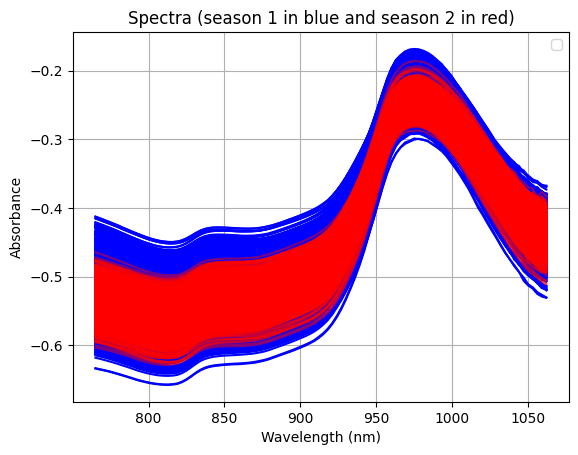

Season:  3
(4966, 100)


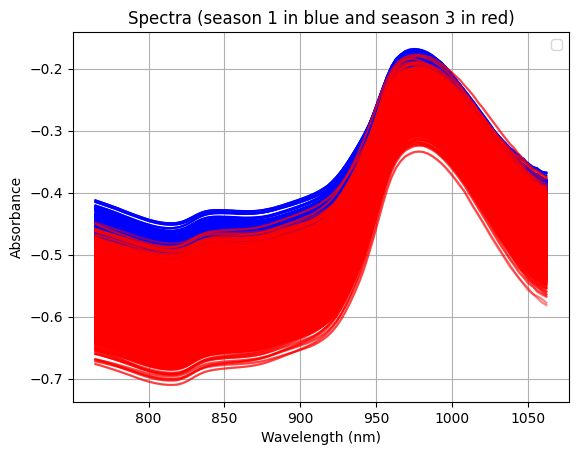

Season:  4
(1448, 100)


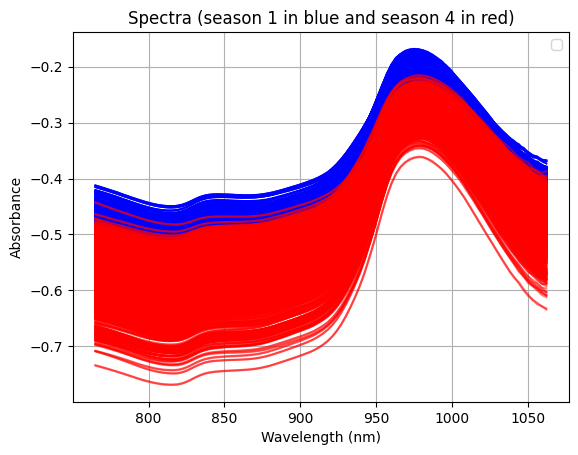

Season:  5
(320, 100)


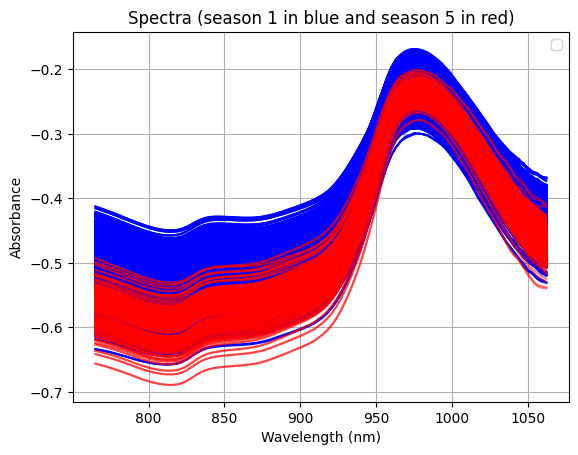

In [6]:
following_seasons = seasons[1:]
for i, season in enumerate(following_seasons):
    print("Season: ", season)
    X, y = get_samples_Xy_by_season(mat, season)
    print(X.shape)  
    plt.plot(wv_range.T,initial_model_X.T, c = "blue")
    plt.plot(wv_range.T,X.T, c = "red", alpha = 0.5)
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Absorbance")
    plt.title("Spectra (season 1 in blue and season " + str(i+2) + " in red)")
    plt.legend(loc = 0)
    plt.grid()
    plt.show()

We train PLS models with 1 to 20 components and evaluate each using 10-fold cross-validation. The model with the lowest cross-validated RMSE is selected as optimal.

100.0% completed
Suggested number of components: 20


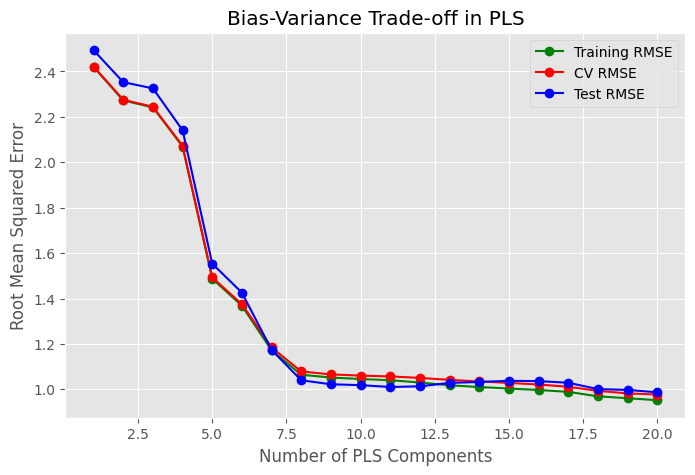

In [7]:
from helperfunctions.optimize import optimise_pls_cv_test
from sklearn.model_selection import train_test_split

split_ratio = 0.8
n_samples = initial_model_X.shape[0]
initial_season_X_train, initial_season_X_test, initial_season_y_train, initial_season_y_test= train_test_split(initial_model_X, initial_model_y, train_size=split_ratio, random_state=42)
opt_n_comp = optimise_pls_cv_test(initial_season_X_train, initial_season_y_train, initial_season_X_test, initial_season_y_test, n_comp=20)

Seeing that the gains in stagnate pretty quickly, we can choose to select fewer number of components then the function tells us is optimal. Doing so will create a more robust model

In [8]:
opt_n_comp = 8

Text(0.5, 1.0, 'Cross-validated predictions')

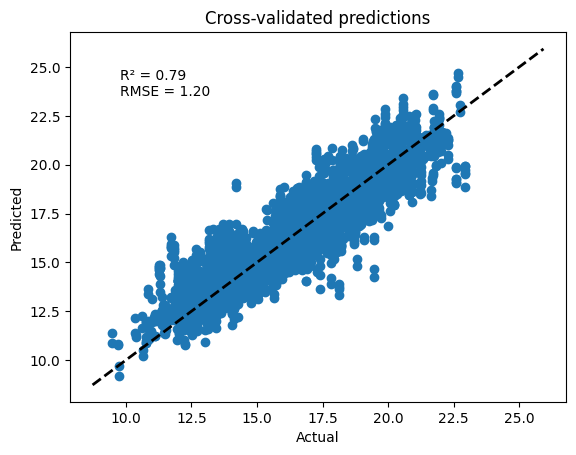

In [12]:
from sklearn.calibration import cross_val_predict
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import root_mean_squared_error
from helperfunctions.plot_functions import r2_score

pls = PLSRegression(n_components=opt_n_comp)
pls.fit(initial_season_X_train, initial_season_y_train)
y_cv = cross_val_predict(pls, initial_model_X, initial_model_y, cv=10)
r2_cv = r2_score(initial_model_y, y_cv)
rmse_cv = root_mean_squared_error(initial_model_y, y_cv)
fig, ax = plt.subplots()
vmin = min(initial_model_y.min(), y_cv.min())*0.95
vmax = max(initial_model_y.max(), y_cv.max())*1.05
plt.plot([vmin, vmax], [vmin, vmax], 'k--', lw=2)
plt.scatter(initial_model_y, y_cv)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.text(.1, .9, f"R² = {r2_cv:.2f}\nRMSE = {rmse_cv:.2f}",
        horizontalalignment='left',
        verticalalignment='top',
        transform=ax.transAxes)
plt.title("Cross-validated predictions")

The model seems to perform quite well on the first season data. Let's how it will deal with the data from the next seasons.

## Model Performance Across Seasons
After training the initial model, we test its predictions on data from subsequent seasons. This helps us observe how well the model generalizes and where it may start to fail due to changes in the data.

Season:  2


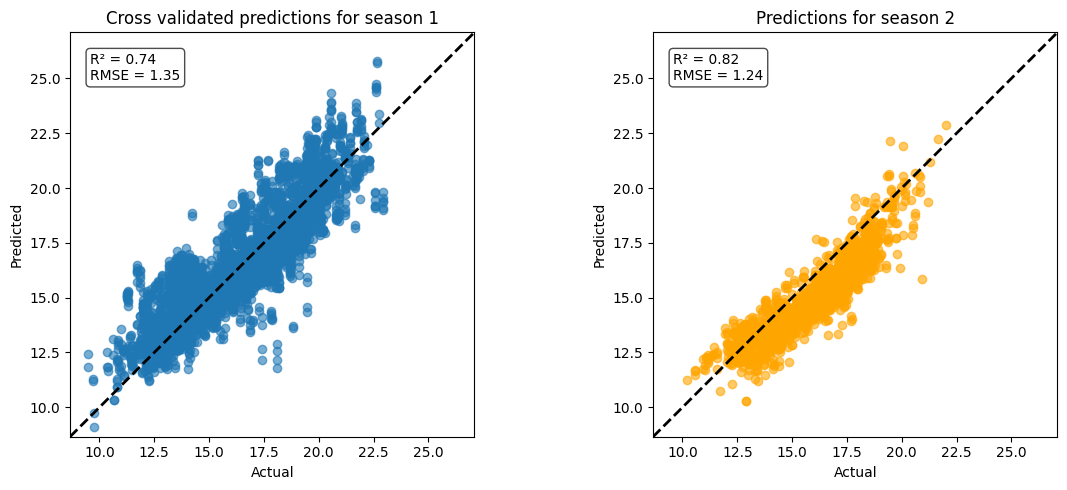

Season:  3


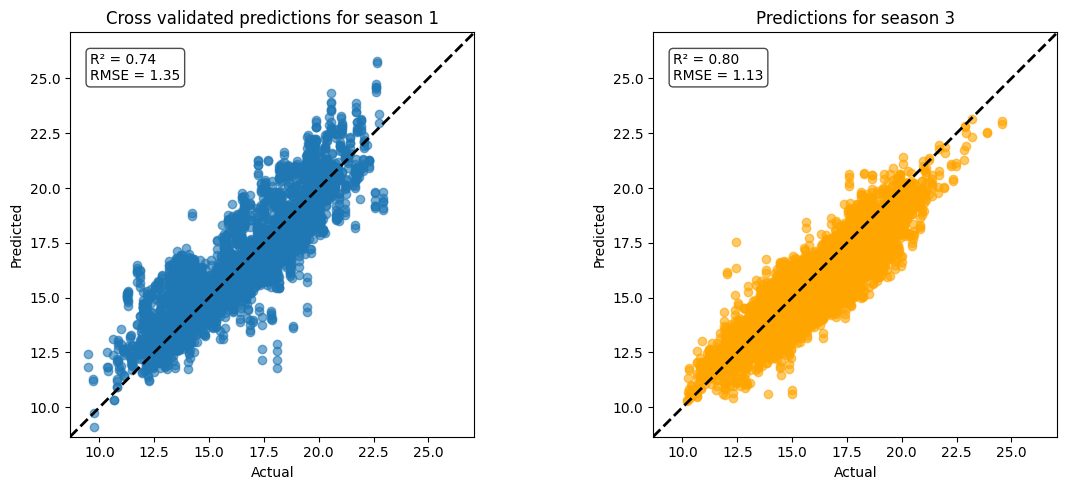

Season:  4


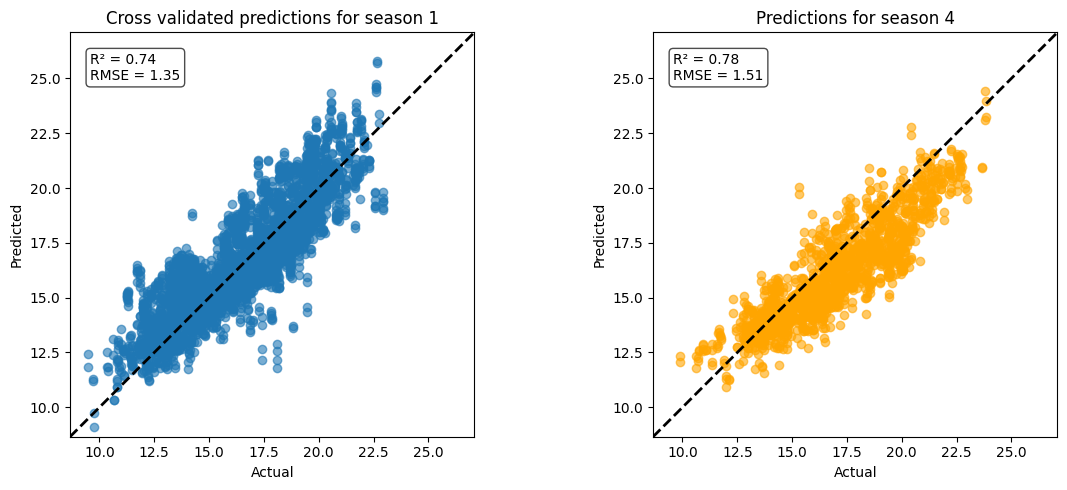

Season:  5


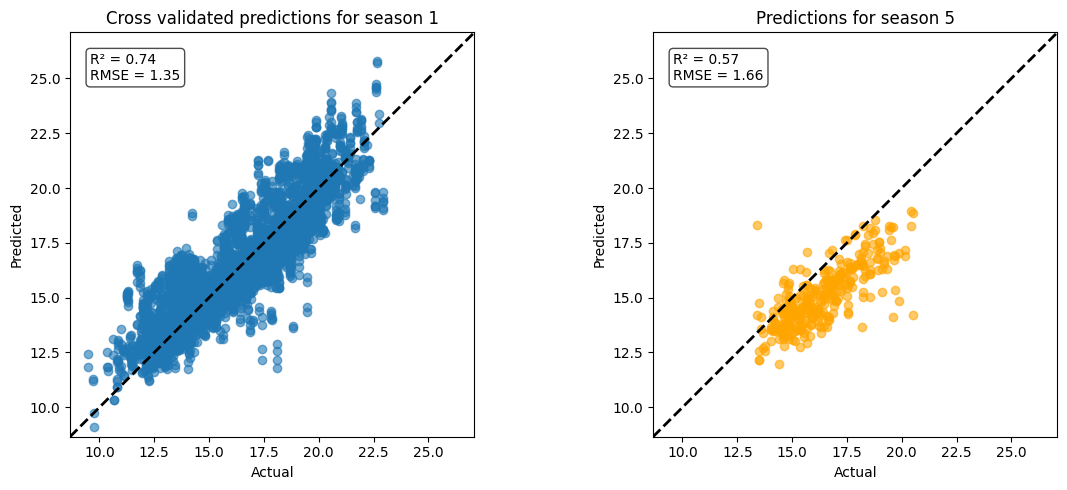

In [34]:
from helperfunctions.plot_functions import plot_cv_vs_test

for i,season in enumerate(following_seasons):
    print("Season: ", season)
    X, y = get_samples_Xy_by_season(mat, season)
    y_test_pred = pls.predict(X)
    plot_cv_vs_test(initial_model_y, y_cv, y, y_test_pred, ["Cross validated predictions for season 1", "Predictions for season "+str(i+2)])

## Monitoring for erroneous measurements

Let's look at some methods for monitoring model errors and bias over time. We use statistical tests and visualization to detect outliers, drift, and systematic errors in predictions, which are critical for maintaining model reliability.

In [35]:
from scipy.stats import chi2
from scipy.stats import bootstrap

confidence = 0.95
# Function to determine the confidence limit of Q residuals with bootstrapping 
def q2_limit_func(d, quantile = confidence):
    return np.quantile(d, q = quantile)

# T2 hotelling
plsr_tscores = pls.transform(X=initial_season_X_train)
plsr_scale_values_t2 = plsr_tscores.var(axis=0)
plsr_hotelling_t2 = np.diag(plsr_tscores.dot(np.diag(1/plsr_scale_values_t2)).dot(plsr_tscores.T))
plsr_t2_thres = chi2(opt_n_comp).isf(1-confidence)

# Q residuals
plsr_xcal_hat = pls.inverse_transform(plsr_tscores)
plsr_q2_residuals = np.sqrt(np.sum(np.power(initial_season_X_train - plsr_xcal_hat,2),axis=1))
_, plsr_q2_thres = bootstrap((plsr_q2_residuals,), q2_limit_func, n_resamples=1000, vectorized=False).confidence_interval


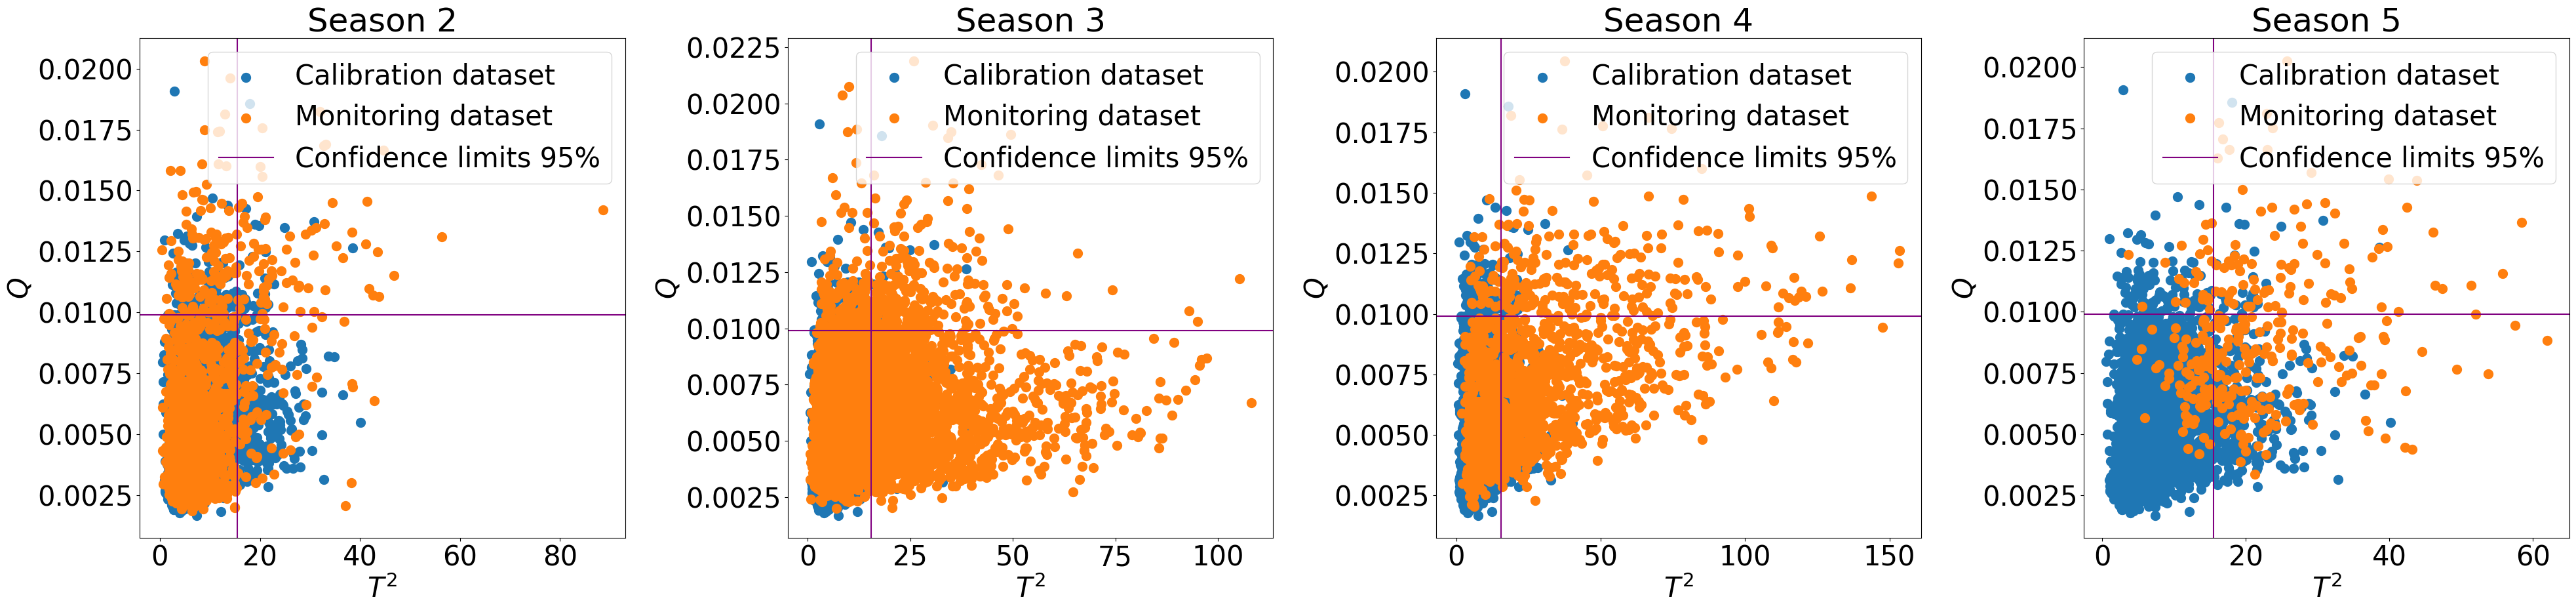

In [36]:
plt.rcParams['font.size'] = 30
fig, axs = plt.subplots(1, 4, figsize=(40,10))

for i, season in enumerate(seasons[1:]):
    Xtar = mat['sp'][mat['season'].flatten() == season]
    tscores_test = pls.transform(Xtar)
    hotelling_t2_test = np.diag(tscores_test.dot(np.diag(1 / plsr_scale_values_t2)).dot(tscores_test.T))
    q_residuals_test = np.sqrt(np.sum(np.power(Xtar - pls.inverse_transform(tscores_test), 2), axis=1))

    axs[i].scatter(plsr_hotelling_t2, plsr_q2_residuals, label="Calibration dataset", linewidth=5)
    axs[i].scatter(hotelling_t2_test, q_residuals_test, label=f"Monitoring dataset", linewidth=5)
    axs[i].axvline(x=plsr_t2_thres, c="purple", label=f"Confidence limits {int(confidence*100)}%")
    axs[i].axhline(y=plsr_q2_thres, c="purple")
    axs[i].legend()
    axs[i].set_xlabel("$T^2$")
    axs[i].set_ylabel("$Q$")
    axs[i].set_title(f"Season {season}")

plt.tight_layout()
plt.show()


You can see especially in the last season, where the data was measured with a different instrument the mean of the distribution really shifts. 

## Bias monitoring

In this section, we evaluate the bias of the PLS model across different seasons. Bias is the average difference between the predicted and actual values of mango dry matter content. Monitoring bias helps us detect systematic errors or drift in model predictions over time.

- **Bias monitoring**: For each season, we calculate the mean difference between the model predictions (`y_pred`) and the true values (`y_tar`). This shows how much the model's predictions deviate from reality for each season.
- **Real bias**: We also compute the bias after recentering the model using the mean of the calibration data (`y_mean`) and the mean spectrum (`x_mean`). This adjustment accounts for possible shifts in the data distribution.
- The plot visualizes both the monitored bias and the real bias for each season, helping us assess model stability and the need for recalibration.

This analysis is crucial for identifying when the model may require maintenance or correction due to changes in the data over time.

In [37]:
y_mean = initial_season_y_train.mean()
bias_seasons = []
bias_real_seasons = []
for season in seasons:
    X_tar, y_tar = get_samples_Xy_by_season(mat, season)
    y_pred = pls.predict(X_tar)
    bias = np.mean(y_pred - y_tar)
    x_mean = X_tar.mean(axis=0)
    beta_recenter = y_mean - x_mean.dot(pls.coef_.T)
    xtest_pls = initial_season_X_test.copy()
    ytest_pls = initial_season_y_test.copy()

    ytest_pls_pred = xtest_pls.dot(pls.coef_.T) + beta_recenter
    bias_real = np.mean(ytest_pls - ytest_pls_pred)
    bias_seasons.append(bias)
    bias_real_seasons.append(bias_real)

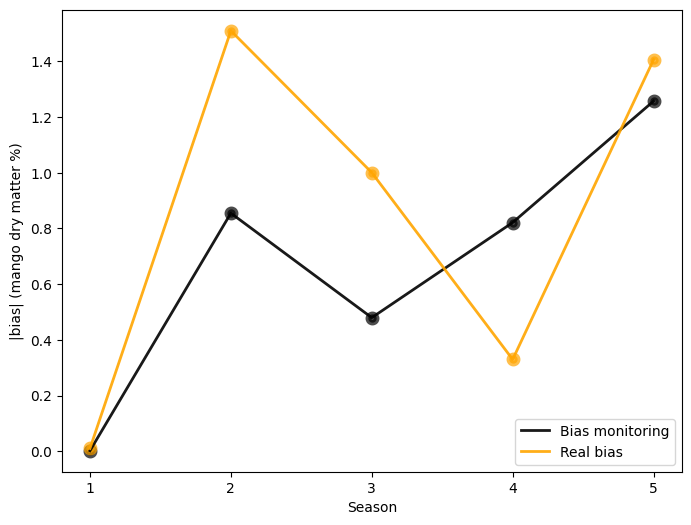

In [38]:
plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize = (8,6))

ax.plot(seasons, np.abs(bias_seasons), color = "k", linewidth = 2, alpha = 0.9, label = "Bias monitoring")
ax.scatter(seasons, np.abs(bias_seasons), color = "k", linewidth = 4, alpha = 0.7)

ax.plot(seasons, np.abs(bias_real_seasons), color = "orange", linewidth = 2, alpha = 0.9, label = "Real bias")
ax.scatter(seasons, np.abs(bias_real_seasons), color = "orange", linewidth = 4, alpha = 0.7)

ax.set_xticks(seasons)
ax.set_xlabel("Season")
ax.set_ylabel("|bias| (mango dry matter %)")
ax.legend()
plt.show()

The plot above compares the absolute bias of the PLS model predictions across different seasons. 

- **Black line and dots ("Bias monitoring")**: Show the absolute mean difference between predicted and actual mango dry matter content for each season, using the original calibration.
- **Orange line and dots ("Real bias")**: Show the bias after recentering the model using the mean of the calibration data and mean spectrum, which adjusts for possible shifts in the data distribution.

A low bias indicates that the model predictions are close to the true values, while a high bias suggests systematic error or drift. If the bias increases in later seasons, it means the model's accuracy degrades over time, highlighting the need for recalibration or correction. The comparison between monitored and real bias helps identify whether simple recentering can correct the drift or if more advanced maintenance is needed.

## PCA monitoring

### PCA Monitoring Explanation
Principal Component Analysis (PCA) is used here to monitor the structure and variance of the spectral data over different seasons. By projecting the data onto principal components, we can visualize and detect shifts, outliers, or changes in the underlying data distribution. This helps identify whether the data collected in new seasons is consistent with the calibration set, or if there are systematic changes that could affect model performance. Monitoring with PCA is a key step in chemometric model maintenance, as it provides early warning of data drift or anomalies before they impact predictions.

In [39]:
ncp = 5

Tcorr_all = []

for season in seasons:
    Xtar = get_samples_Xy_by_season(mat, season)[0]
    # SVD on target season data (centered)
    _,St,Vtt = np.linalg.svd(Xtar - Xtar.mean(axis=0))    
    St = np.diag(St[0:ncp])
    Vt = Vtt.T[:, 0:ncp]

    # SVD on calibration (training) data (centered)
    Us,Ss,Vst = np.linalg.svd(initial_season_X_train - initial_season_X_train.mean(axis=0))    
    Ss = np.diag(Ss[0:ncp])
    Us = Us[:, 0:ncp]

    # Project calibration data onto its own PCs and onto target PCs
    Tsou_cal = (Us).dot(Ss)
    Xsou_cal_c = initial_season_X_train - initial_season_X_train.mean(axis=0) 
    Tsou_cal_hat = (Xsou_cal_c).dot(Vt)
    
    Tcorr = np.zeros(ncp)

    for h in range(ncp):

        Tcorr[h] = np.abs(np.corrcoef(Tsou_cal[:,h:(h+1)].T, Tsou_cal_hat[:,h:(h+1)].T)[0,1])
        
    
    Tcorr_all.append(Tcorr)

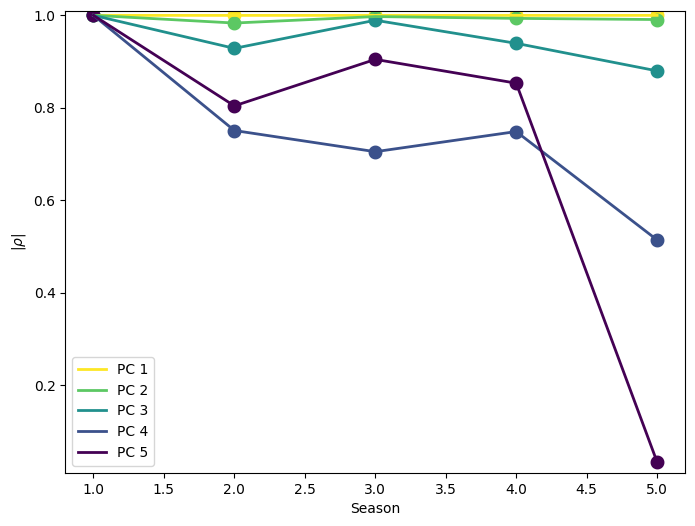

In [40]:
import matplotlib
color_var = np.arange(1, ncp+1)
min_color_var = np.amin(color_var)
max_color_var = np.amax(color_var)
c_m = matplotlib.cm.viridis_r
norm = matplotlib.colors.Normalize(vmin = min_color_var, vmax = max_color_var)
s_m = matplotlib.cm.ScalarMappable(cmap = c_m, norm = norm)



fig, ax = plt.subplots(figsize = (8,6))

for h in range(ncp):
    color_tuple = s_m.to_rgba(h+1)
    
    ax.plot(seasons, [x[h] for x in Tcorr_all], color = color_tuple, linewidth = 2, label = "PC " + str(h+1))
    ax.scatter(seasons, [x[h] for x in Tcorr_all], color = color_tuple, linewidth = 4)

ax.set_ylabel(r"|$\rho$|")
ax.set_xlabel("Season")
ax.set_ylim(0.01,1.01)
ax.legend()
plt.show()

In [41]:
data_dict_varexpl = mat.copy()
data_dict_varexpl[f"X_{1:d}"] = initial_model_X.copy()
data_dict_varexpl[f"Y_{1:d}"] = initial_model_y.copy()

varexpl_all = []

for season in seasons:    
    Xpca = get_samples_Xy_by_season(mat, season)[0].copy()
    V, D, Vt = np.linalg.svd(np.cov(Xpca.T, ddof = 0))
    var_explained = np.cumsum(D/np.sum(D))
    varexpl = 100*var_explained[0:ncp]
    varexpl_all.append(varexpl)

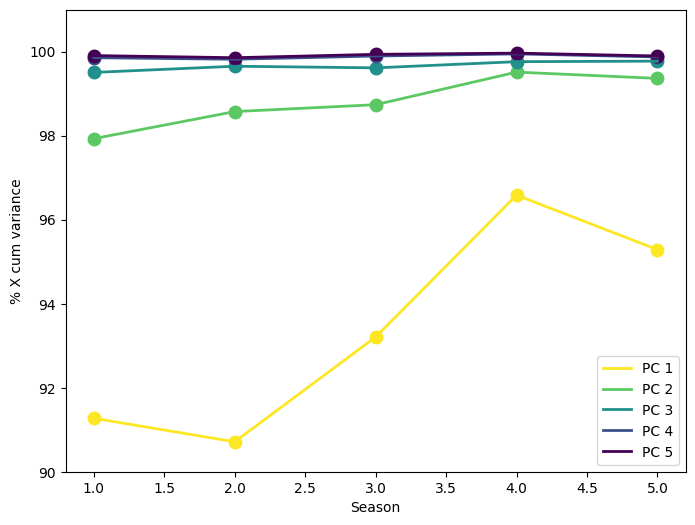

In [42]:
fig, ax = plt.subplots(figsize = (8,6))

for h in range(ncp):
    color_tuple = s_m.to_rgba(h+1)
    ax.plot(seasons, [x[h] for x in varexpl_all], color = color_tuple, linewidth = 2, label = "PC " + str(h+1))
    ax.scatter(seasons, [x[h] for x in varexpl_all], color = color_tuple, linewidth = 4)


ax.set_ylabel("% X cum variance")
ax.set_xlabel("Season")
ax.set_ylim(90,101)
ax.legend()
plt.show()

## Model correction by applying DOP

In this final section, we apply Dynamic Orthogonal Projection (DOP) to correct the model for drift and systematic errors detected in previous steps. This technique helps restore model accuracy and robustness for new data batches.

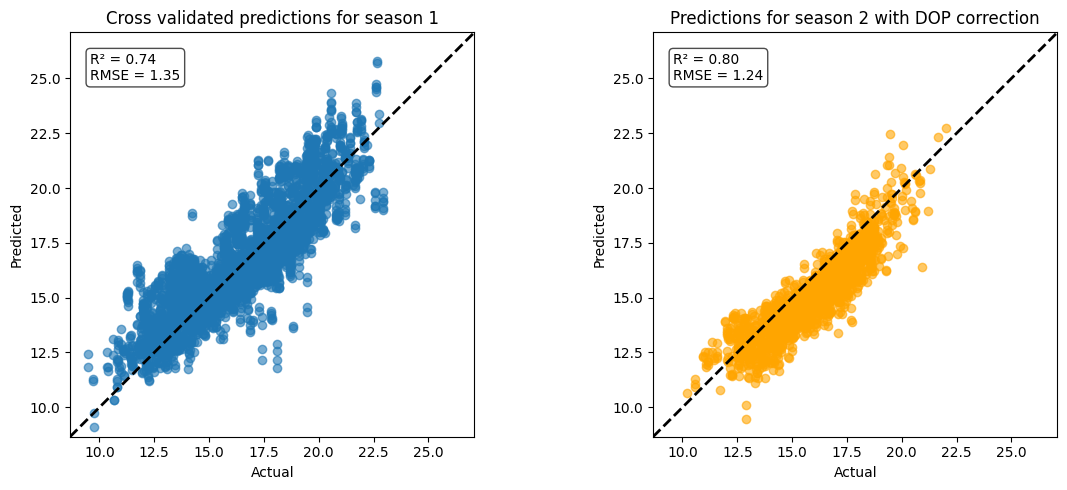

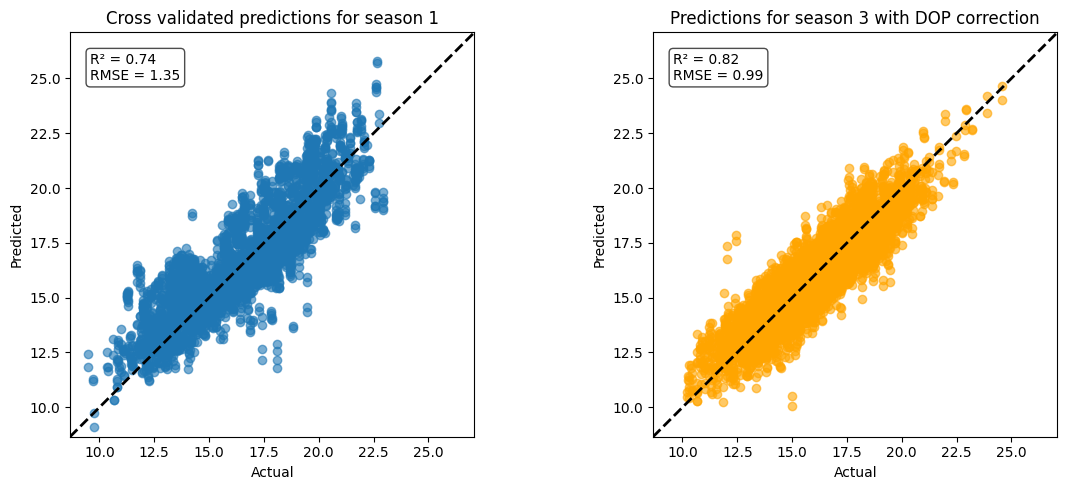

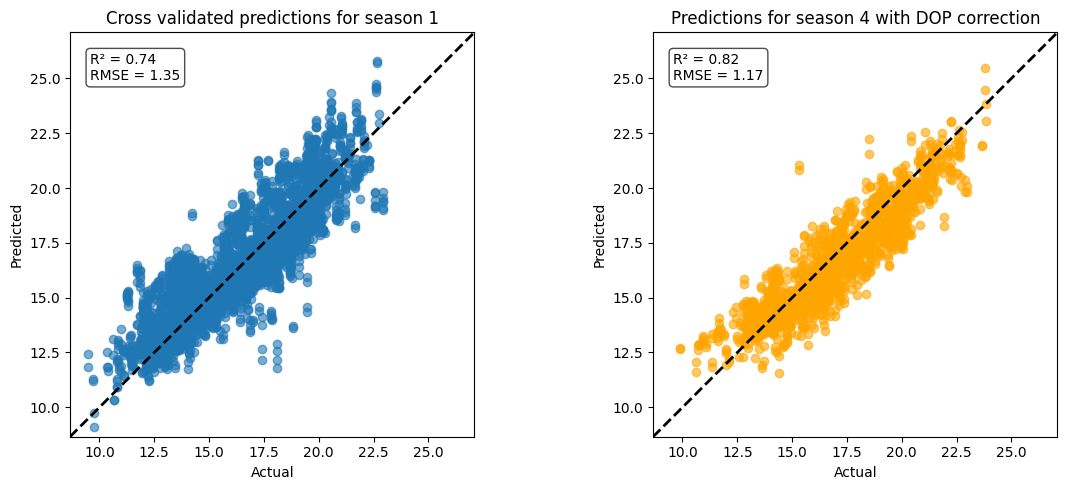

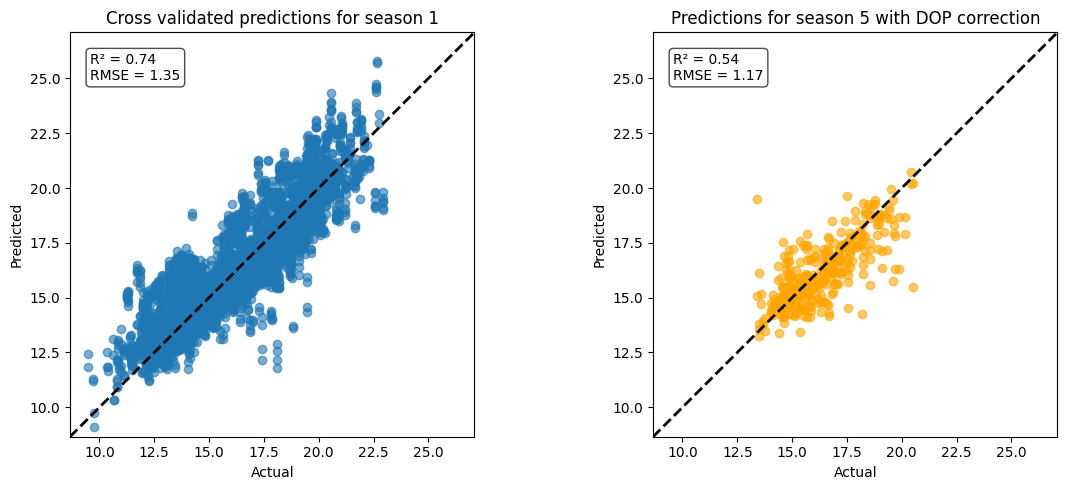

In [44]:
import pycaltransfer.caltransfer as caltransfer

y_initial_pred = y_cv.copy()
y_initial_true = initial_model_y.copy()

plt.rcParams['font.size'] = 10
for i,season in enumerate(following_seasons):
    Xsou = initial_model_X
    Xtar = mat["sp"][mat["season"].flatten() == season][0:50]
    Ysou = initial_model_y
    Ytar = mat["dm"][mat["season"].flatten() == season][0:50]
    # DOP
    E = caltransfer.dop(Xsou, Ysou, Xtar, Ytar, rho = 15, dop_ncomp = 2) 
    Xsou_e = Xsou.dot(E) 
    x_mean_e = np.mean(Xsou_e, axis = 0)
    x_mean_e.shape = (1,Xsou_e.shape[1])
    y_mean = np.mean(Ysou, axis = 0)
    # PLSR after DOP
    pls2 = PLSRegression(n_components=opt_n_comp,scale=False)
    pls2.fit(Xsou_e, Ysou)
    y_cv = cross_val_predict(pls2, Xsou_e, Ysou)

    y_pred_new_season = pls2.predict(mat["sp"][mat["season"].flatten() == season])
    plot_cv_vs_test(y_initial_true, y_initial_pred, mat["dm"][mat["season"].flatten() == season], y_pred_new_season, ["Cross validated predictions for season 1", "Predictions for season "+str(i+2) + " with DOP correction"])